In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

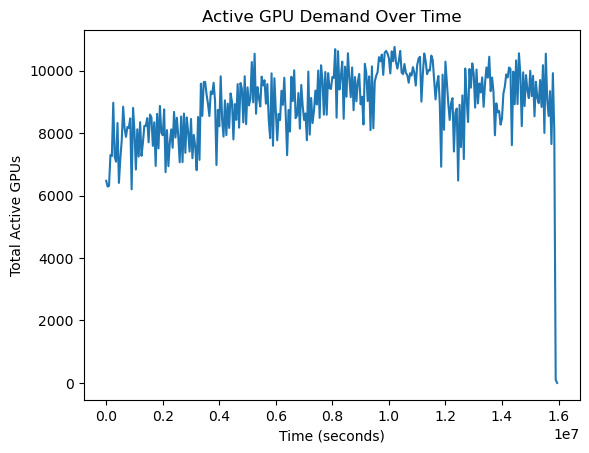

In [ ]:
df = pd.read_csv("job_info_df.csv")

#convert all columns to numbers
df["submit_time"] = pd.to_numeric(df["submit_time"], errors="coerce")
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["gpu_request"] = pd.to_numeric(df["gpu_request"], errors="coerce")
df["worker_num"] = pd.to_numeric(df["worker_num"], errors="coerce")

df = df.dropna()

BIN_SIZE = 50000   # size of each time window (seconds)

t_start = int(df["submit_time"].min())
t_end = int((df["submit_time"] + df["duration"]).max())
time_bins = np.arange(t_start, t_end + BIN_SIZE, BIN_SIZE)

gpu_demand = []

for t in time_bins:
    active_jobs = df[(df["submit_time"] <= t) & 
                     (df["submit_time"] + df["duration"] > t)]
    
    total_gpu = (active_jobs["gpu_request"] * active_jobs["worker_num"]).sum()
    gpu_demand.append(total_gpu)

plt.figure()
plt.plot(time_bins, gpu_demand)
plt.xlabel("Time (seconds)")
plt.ylabel("Total Active GPUs")
plt.title("Active GPU Demand Over Time")
plt.show()